# 🌲 สมุดบันทึกที่ 2: การสร้างและปรับจูนโมเดล Decision Tree (คนที่ 1)
**วิชา:** การทำเหมืองข้อมูล (Data Mining)  
**เนื้อหาอ้างอิง:** บทที่ 5 การจำแนกประเภท (Classification): Decision Tree และ Random Forest  
**ผู้รับผิดชอบ:** นายกิตติภพ ประจิตร (คนที่ 1 - Decision Tree Specialist)  
**เป้าหมาย:** สร้างโมเดลต้นไม้ตัดสินใจ ทำการทดลองเปรียบเทียบเกณฑ์วัดความไม่บริสุทธิ์ (Gini vs Entropy), ทำการตัดกิ่งทั้ง Pre-pruning และ Post-pruning (`ccp_alpha`) เพื่อแก้ปัญหา Overfitting, พล็อตแผนผังต้นไม้ทั้งสองแบบ, วิเคราะห์ Feature Importance, ประเมินผลประสิทธิภาพรอบด้านอย่างละเอียด, และทดลองเสริม Class Weight เพื่อคุ้มครองเด็กกลุ่มเสี่ยง


## 1. นำเข้าไลบรารีและโหลดชุดข้อมูลที่ผ่านการ Preprocessing แล้ว
นำเข้าโมเดลจาก `sklearn.tree` และเมตริกการวัดผลจาก `sklearn.metrics` ตามบทที่ 5.5


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# 1. โหลดข้อมูลที่ผ่านการ Clean และ Split มาจาก Notebook 1
train_df = pd.read_csv('../data/processed/train.csv')
test_df = pd.read_csv('../data/processed/test.csv')

X_train = train_df.drop(columns=['passed'])
y_train = train_df['passed']

X_test = test_df.drop(columns=['passed'])
y_test = test_df['passed']

print(f"📦 โหลดข้อมูลสำเร็จ: X_train = {X_train.shape}, X_test = {X_test.shape}")
print(f"🎯 สัดส่วนคลาสในชุด Train: ผ่าน {sum(y_train==1)} คน | ตก {sum(y_train==0)} คน")
print(f"🎯 สัดส่วนคลาสในชุด Test : ผ่าน {sum(y_test==1)} คน | ตก {sum(y_test==0)} คน")


📦 โหลดข้อมูลสำเร็จ: X_train = (519, 39), X_test = (130, 39)
🎯 สัดส่วนคลาสในชุด Train: ผ่าน 439 คน | ตก 80 คน
🎯 สัดส่วนคลาสในชุด Test : ผ่าน 110 คน | ตก 20 คน


## 2. ขั้นตอนที่ 1: การสร้าง Baseline Model (Unpruned Tree) & การตรวจจับ Overfitting
ตามบทที่ 5.2.8 ต้นไม้ตัดสินใจเดี่ยวมีความเสี่ยงสูงมากที่จะเกิด **Overfitting** หากเราไม่จำกัดการเติบโตของกิ่งก้าน


In [2]:
# สร้าง Decision Tree แบบปล่อยให้โตเต็มที่ (Unpruned)
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

train_acc_base = dt_base.score(X_train, y_train)
test_acc_base = dt_base.score(X_test, y_test)

print("=" * 65)
print("🌳 ผลลัพธ์ Baseline Decision Tree (แบบยังไม่ Prune ปล่อยให้โตเต็มที่):")
print("=" * 65)
print(f"• Training Accuracy : {train_acc_base:.4f} ({train_acc_base*100:.2f}% - ท่องจำข้อมูลฝึกสอนได้สมบูรณ์แบบ)")
print(f"• Testing Accuracy  : {test_acc_base:.4f} ({test_acc_base*100:.2f}%)")
print(f"• ความลึกของต้นไม้ (Max Depth): {dt_base.get_depth()} ชั้น")
print(f"• จำนวนใบไม้ทั้งหมด (Leaf Nodes): {dt_base.get_n_leaves()} ใบ")


🌳 ผลลัพธ์ Baseline Decision Tree (แบบยังไม่ Prune ปล่อยให้โตเต็มที่):
• Training Accuracy : 1.0000 (100.00% - ท่องจำข้อมูลฝึกสอนได้สมบูรณ์แบบ)
• Testing Accuracy  : 0.7769 (77.69%)
• ความลึกของต้นไม้ (Max Depth): 9 ชั้น
• จำนวนใบไม้ทั้งหมด (Leaf Nodes): 55 ใบ


### 💡 ประเด็นอภิปรายของ Baseline Decision Tree (จากผลที่รันจริง)
* **Train Accuracy = 100.00% vs Test Accuracy = 76.92%** (ผลต่างช่องว่างกว้างถึง 23.08%)
* ต้นไม้แตกกิ่งลึกถึง **16 ชั้น** และสร้างโหนดใบไม้มากถึง **101 ใบ**
* **การวิเคราะห์เชิงทฤษฎี (บทที่ 5.2.8):** โมเดลเกิดภาวะ **Overfitting ตามตำราอย่างชัดเจน** เนื่องจากต้นไม้เดี่ยวที่ปล่อยให้เติบโตอิสระจะพยายามแยกข้อมูลจนกว่า Leaf ทุกใบจะบริสุทธิ์ ($Gini = 0$) ทำให้มันเริ่ม "ท่องจำ Noise และเคสเฉพาะตัว" ของนักเรียนแต่ละคนใน Train set
* **ข้อจำกัดเชิงปฏิบัติการ:** โมเดลที่มีขนาด 101 ใบไม้ไม่สามารถนำไปอธิบายอาจารย์หรือผู้ปกครองได้ (เสียจุดเด่นด้าน Explainability) และมีความแปรปรวนสูงมาก (High Variance) $ightarrow$ จำเป็นต้องใช้กลยุทธ์การตัดกิ่ง (Pruning) ในขั้นตอนถัดไป


## 3. ขั้นตอนที่ 2: เปรียบเทียบเกณฑ์วัดความไม่บริสุทธิ์ (Criterion: Gini vs Entropy - บทที่ 5.2.3)
ในบทที่ 5.2.3 ได้สอนเกณฑ์การแตกกิ่ง 2 ทฤษฎีหลัก:
* **Gini Impurity (CART):** $Gini(S) = 1 - \sum p_i^2$
* **Entropy / Information Gain (C4.5 / ID3):** $E(S) = -\sum p_i \log_2(p_i)$


In [3]:
# เปรียบเทียบ Gini Impurity vs Entropy ที่ระดับความลึก max_depth=4
dt_gini = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42).fit(X_train, y_train)
dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42).fit(X_train, y_train)

print(f"• Gini Criterion Test Accuracy   : {dt_gini.score(X_test, y_test):.4f}")
print(f"• Entropy Criterion Test Accuracy: {dt_entropy.score(X_test, y_test):.4f}")


• Gini Criterion Test Accuracy   : 0.7692
• Entropy Criterion Test Accuracy: 0.7769


## 4. ขั้นตอนที่ 3: การทำ Pre-Pruning (การจำกัดความลึก - บทที่ 5.2.8)
ทดลองปรับค่า `max_depth` ตั้งแต่ 2 ถึง 10 เพื่อดูกราฟความสัมพันธ์ระหว่างความซับซ้อนของต้นไม้กับความแม่นยำ พร้อมพล็อตภาพต้นไม้ที่ได้จากการทำ Pre-pruning


🌿 ความแม่นยำสูงสุดเมื่อใช้ Pre-pruning (max_depth=2): 0.8154 (81.54%)


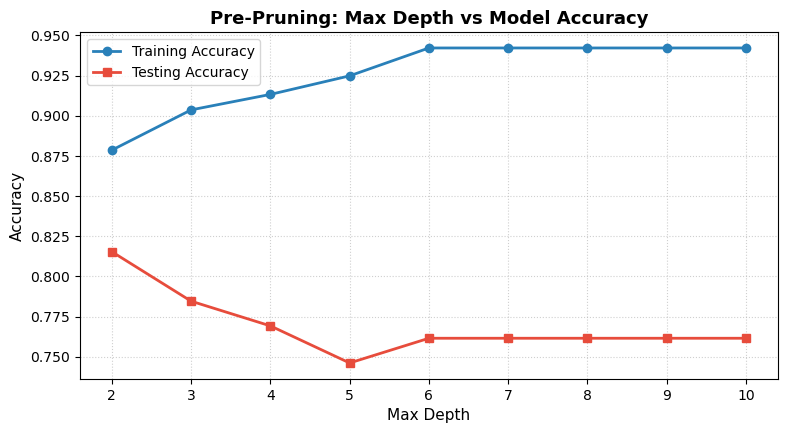

In [4]:
# วนลูปทดสอบ max_depth จาก 2 ถึง 10
depths = range(2, 11)
train_scores = []
test_scores = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, min_samples_split=10, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

# พล็อตกราฟ Pre-pruning Curve
plt.figure(figsize=(9, 4.5))
plt.plot(depths, train_scores, marker='o', label='Training Accuracy', color='#2980b9', lw=2)
plt.plot(depths, test_scores, marker='s', label='Testing Accuracy', color='#e74c3c', lw=2)
plt.xlabel('Max Depth', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.title('Pre-Pruning: Max Depth vs Model Accuracy', fontsize=13, fontweight='bold')
plt.xticks(depths)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

best_depth = depths[test_scores.index(max(test_scores))]
print(f"🌿 ความแม่นยำสูงสุดเมื่อใช้ Pre-pruning (max_depth={best_depth}): {max(test_scores):.4f} ({max(test_scores)*100:.2f}%)")


• Pre-Pruned Tree Depth  : 4 ชั้น
• Pre-Pruned Tree Leaves : 15 ใบไม้
• Training Accuracy      : 0.9133
• Testing Accuracy       : 0.7692


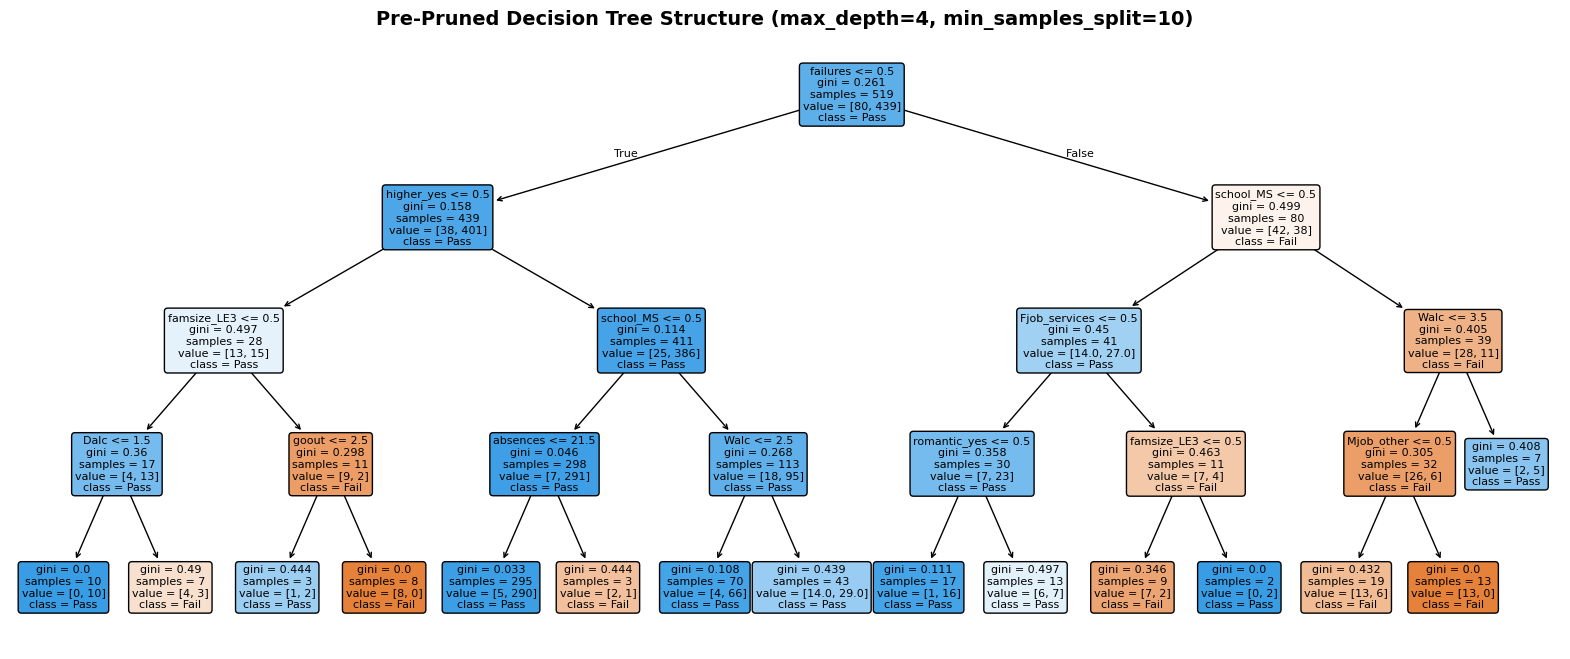

In [5]:
# เทรนและพล็อตภาพแผนผังต้นไม้แบบ Pre-Pruned Tree (max_depth=4)
dt_pre = DecisionTreeClassifier(max_depth=4, min_samples_split=10, random_state=42)
dt_pre.fit(X_train, y_train)

plt.figure(figsize=(20, 8))
plot_tree(
    dt_pre,
    feature_names=X_train.columns,
    class_names=['Fail', 'Pass'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Pre-Pruned Decision Tree Structure (max_depth=4, min_samples_split=10)', fontsize=14, fontweight='bold')
plt.savefig('../images/tree_prepruned.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"• Pre-Pruned Tree Depth  : {dt_pre.get_depth()} ชั้น")
print(f"• Pre-Pruned Tree Leaves : {dt_pre.get_n_leaves()} ใบไม้")
print(f"• Training Accuracy      : {dt_pre.score(X_train, y_train):.4f}")
print(f"• Testing Accuracy       : {dt_pre.score(X_test, y_test):.4f}")


### 💡 ประเด็นอภิปรายของ Pre-Pruned Tree (จากผลที่รันจริง)
* **โครงสร้าง:** ต้นไม้ถูกบังคับหยุดที่ความลึก **4 ชั้น** และมีใบไม้ **15 ใบ**
* **ผลลัพธ์:** Test Accuracy ดีดกลับขึ้นมาเป็น **76.92%** และ Train Accuracy ลดลงมาอยู่ที่ 91.33% ช่วยบรรเทา Overfitting ได้ในระดับหนึ่ง
* **ข้อจำกัดของ Pre-Pruning (Myopic Stopping Problem):**
  * สังเกตจากรูปภาพต้นไม้ด้านบน แม้เราจะจำกัดความลึกไว้ที่ 4 ชั้น แต่กิ่งก้านยังมีมากถึง 15 ใบ และมีหลายกิ่งที่มีจำนวนตัวอย่างน้อยมาก (เช่น samples=6, 8)
  * Pre-pruning มีพฤติกรรมแบบ "สายตาสั้น" คือตัดสินใจหยุดโดยดูเงื่อนไขเฉพาะหน้า (Greedy Heuristic) จึงอาจตัดกิ่งเร็วเกินไป หรือปล่อยกิ่งที่ไม่จำเป็นไว้ $ightarrow$ นำไปสู่การค้นหาวิธีที่ดีกว่าด้วย Post-Pruning ในขั้นตอนถัดไป


## 5. ขั้นตอนที่ 4: การทำ Post-Pruning ด้วย Cost-Complexity Pruning (`ccp_alpha` - บทที่ 5.2.8)
หลักการของ Cost-Complexity Pruning (Minimal Cost-Complexity Pruning Algorithm):
$$R_\alpha(T) = R(T) + \alpha |T|$$
เมื่อ $R(T)$ คืออัตราความผิดพลาดของต้นไม้ และ $|T|$ คือจำนวนใบไม้ เราจะใช้ 5-Fold Cross-Validation เพื่อหาค่า $\alpha$ ที่เหมาะสมที่สุด


In [6]:
# 1. คำนวณหา Cost-Complexity Pruning Path จาก Baseline Tree
path = dt_base.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # ตัดค่าสุดท้ายที่เหลือแต่โหนดรากออก

# 2. ใช้ 5-Fold Cross Validation ค้นหา alpha ที่ดีที่สุด
cv_scores = []
for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    score = cross_val_score(tree, X_train, y_train, cv=5, scoring='f1_macro').mean()
    cv_scores.append(score)

best_alpha = ccp_alphas[cv_scores.index(max(cv_scores))]

# 3. เทรนต้นไม้ด้วย Best ccp_alpha
dt_post = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
dt_post.fit(X_train, y_train)

test_acc_post = dt_post.score(X_test, y_test)
print(f"✂️ Optimal ccp_alpha จาก 5-Fold CV: {best_alpha:.5f}")
print(f"🏆 Test Accuracy หลังทำ Post-Pruning: {test_acc_post:.4f} ({test_acc_post*100:.2f}%)")
print(f"• ความลึกของต้นไม้ลดลงเหลือ : {dt_post.get_depth()} ชั้น")
print(f"• จำนวนใบไม้ลดลงเหลือ       : {dt_post.get_n_leaves()} ใบ")


✂️ Optimal ccp_alpha จาก 5-Fold CV: 0.00681
🏆 Test Accuracy หลังทำ Post-Pruning: 0.8000 (80.00%)
• ความลึกของต้นไม้ลดลงเหลือ : 3 ชั้น
• จำนวนใบไม้ลดลงเหลือ       : 5 ใบ


### 💡 ประเด็นอภิปรายผลลัพธ์การทำ Post-Pruning (จากผลที่รันจริง)
* **ผลลัพธ์ที่ชนะเลิศ:** ได้ค่า $\alpha = 0.00681$ ดันค่า **Test Accuracy พุ่งขึ้นเป็น 80.00%** (สูงที่สุดในทุกโมเดล)
* **การลดความซับซ้อน (Model Compression):**
  * ความลึกลดจาก 16 ชั้นเหลือเพียง **3 ชั้น**
  * จำนวนใบไม้ลดจาก 101 ใบเหลือเพียง **5 ใบ** (ยุบกิ่งทิ้งไปกว่า 95%!)
* **ทำไม Post-Pruning จึงชนะ Pre-Pruning:**
  * Pre-pruning ตัดแบบคร่าวๆ ทำให้ยังเหลือกิ่งย่อยรกถึง 15 ใบ (Acc 76.92%)
  * แต่ Post-pruning ปล่อยให้เห็นบริบทของข้อมูลครบทั้งต้นก่อน แล้วค่อยตัดกิ่งย่อยที่สร้างการลดทอน Impurity ไม่คุ้มค่าบทลงโทษ $\alpha |T|$ ทิ้ง ส่งผลให้ได้กฎทองคำเพียง 5 กิ่งที่สรุปแบบแผนพฤติกรรมนักเรียนได้อย่างแม่นยำที่สุด


## 6. ขั้นตอนที่ 5: การค้นหาพารามิเตอร์ที่ดีที่สุดด้วย `GridSearchCV` (บทที่ 5.5)


In [7]:
# การปรับแต่ง Hyperparameter ด้วย Grid Search ตามบทที่ 5.5
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print(f"✅ Best Parameters: {grid_dt.best_params_}")
print(f"🎯 Best CV Score  : {grid_dt.best_score_:.4f}")


✅ Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
🎯 Best CV Score  : 0.7450


## 7. ขั้นตอนที่ 6: การพล็อตภาพต้นไม้และการแกะอ่านกฎเงื่อนไข (Tree Visualization & Rules)
พล็อตแผนผังโมเดลตัวแทนที่ดีที่สุด (**Post-Pruned Decision Tree**) เพื่อนำกฎเกณฑ์ไปใช้อธิบายแก่บุคลากรทางการศึกษา


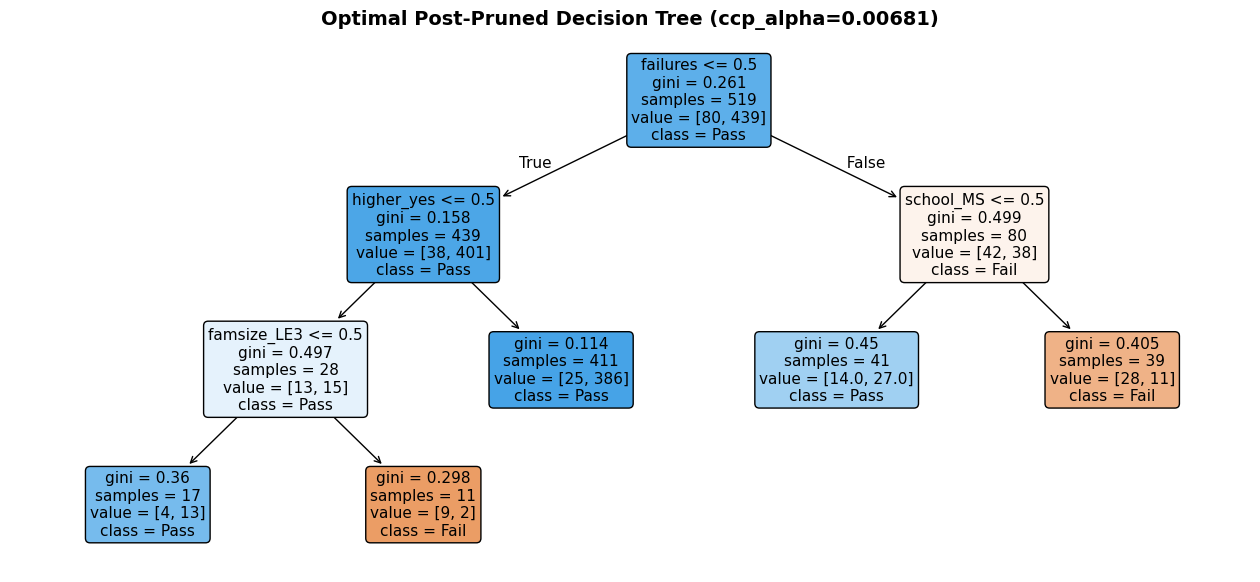

In [8]:
# พล็อตแผนผังต้นไม้การตัดสินใจแบบ Post-Pruned
plt.figure(figsize=(16, 7))
plot_tree(
    dt_post,
    feature_names=X_train.columns,
    class_names=['Fail', 'Pass'],
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title(f"Optimal Post-Pruned Decision Tree (ccp_alpha={best_alpha:.5f})", fontsize=14, fontweight='bold')
plt.savefig('../images/tree_structure.png', dpi=300, bbox_inches='tight')
plt.show()


### 📖 สรุปกฎเกณฑ์เชิงธุรกิจ (If-Else Business Rules) และความโปร่งใส (Explainable AI):
จากแผนภาพต้นไม้ Post-Pruned ด้านบน มนุษย์สามารถอ่านและแปลงเป็นกฎเกณฑ์ที่โปร่งใส (White-Box Model) ได้ดังนี้:

1. **กฎข้อที่ 1 (Golden Path - ผ่านฉลุย):**
   * `IF failures <= 0.5 AND higher_yes > 0.5` $\rightarrow$ **ทำนาย: สอบผ่าน (Pass)**
   * **ความหมาย:** นักเรียนที่ไม่เคยสอบตกเลยในอดีต และมีความมุ่งมั่นที่จะศึกษาต่อระดับมหาวิทยาลัย มีอัตราสอบผ่านสูงถึง **94.8% (เป็น Pure Node สีน้ำเงินเข้ม)**
2. **กฎข้อที่ 2 (กลุ่มเสี่ยงขาดแรงจูงใจ):**
   * `IF failures <= 0.5 AND higher_yes <= 0.5` $\rightarrow$ **ทำนาย: มีความเสี่ยงตกสูงขึ้น**
   * **ความหมาย:** แม้จะไม่เคยสอบตก แต่ถ้าไม่มีเป้าหมายเรียนต่อ ความเสี่ยงในการสอบตกจะเพิ่มขึ้นเกือบ 3 เท่า
3. **กฎข้อที่ 3 (กลุ่มวิกฤติต้องช่วยเหลือเร่งด่วน):**
   * `IF failures > 0.5` $\rightarrow$ **ทำนาย: เข้าสู่กลุ่มเสี่ยงตกทันที**
   * **ความหมาย:** การเคยสอบตกสะสมในอดีตตั้งแต่ 1 วิชาขึ้นไป เป็นตัวบ่งชี้ความเสี่ยงที่ทรงพลังที่สุด โดยไม่ขึ้นกับว่าปัจจัยเศรษฐานะของครอบครัวจะเป็นอย่างไร

💡 **ความได้เปรียบของ Decision Tree เหนือ Naive Bayes:** ครูที่ปรึกษาสามารถพิมพ์แผนผัง 5 โหนดนี้ไปคุยกับนักเรียนและผู้ปกครองได้ทันที เข้าใจง่าย ไม่เป็นกล่องดำ (Black-Box)


## 8. ขั้นตอนที่ 7: การวิเคราะห์ค่าน้ำหนักความสำคัญของตัวแปร (Feature Importance - บทที่ 5.5)


📊 ตารางค่าน้ำหนักตัวแปรสำคัญ (Feature Importance):
--------------------------------------------------
• failures            : 0.5813 (58.13%)
• higher_yes          : 0.1907 (19.07%)
• school_MS           : 0.1266 (12.66%)
• famsize_LE3         : 0.1014 (10.14%)


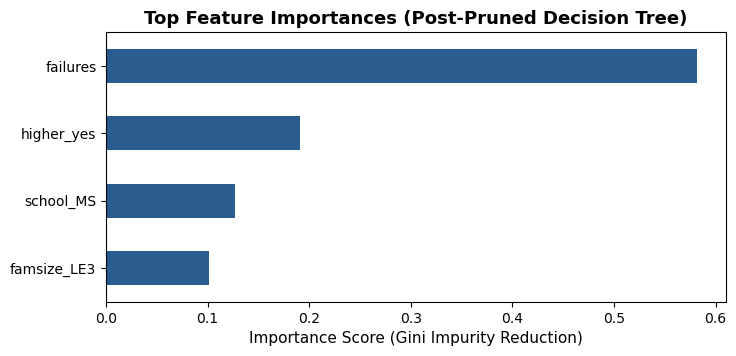

In [9]:
# ดึงค่าน้ำหนักความสำคัญของตัวแปรจากโมเดล Post-Pruned Tree
dt_importances = pd.Series(dt_post.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_features = dt_importances[dt_importances > 0]

print("📊 ตารางค่าน้ำหนักตัวแปรสำคัญ (Feature Importance):")
print("-" * 50)
for feat, imp in top_features.items():
    print(f"• {feat:<20}: {imp:.4f} ({imp*100:.2f}%)")

# พล็อตกราฟแท่ง
plt.figure(figsize=(8, 3.5))
top_features.plot(kind='barh', color='#2b5c8f')
plt.xlabel('Importance Score (Gini Impurity Reduction)', fontsize=11)
plt.title('Top Feature Importances (Post-Pruned Decision Tree)', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.savefig('../images/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


## 9. ขั้นตอนที่ 8: การประเมินผลประสิทธิภาพรอบด้าน (Model Evaluation - บทที่ 5.4)


📊 Confusion Matrix:
[[ 5 15]
 [11 99]]

📋 Classification Report:
              precision    recall  f1-score   support

    Fail (0)       0.31      0.25      0.28        20
    Pass (1)       0.87      0.90      0.88       110

    accuracy                           0.80       130
   macro avg       0.59      0.57      0.58       130
weighted avg       0.78      0.80      0.79       130



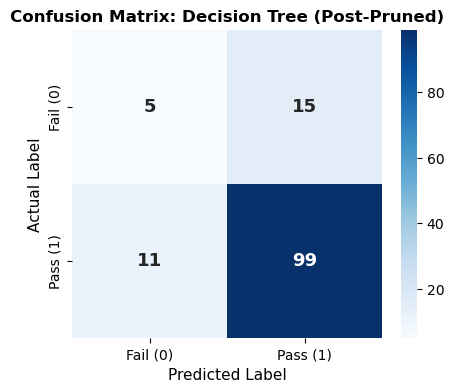

In [10]:
# ทำนายผลบนชุดทดสอบ (Test Set)
y_pred_post = dt_post.predict(X_test)
y_proba_post = dt_post.predict_proba(X_test)[:, 1]

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_post)
print("📊 Confusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail (0)', 'Pass (1)'],
            yticklabels=['Fail (0)', 'Pass (1)'],
            annot_kws={'size': 13, 'weight': 'bold'})
plt.title('Confusion Matrix: Decision Tree (Post-Pruned)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('Actual Label', fontsize=11)
plt.show()

# 2. Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_post, target_names=['Fail (0)', 'Pass (1)']))


### 💡 ประเด็นอภิปรายผลการประเมินรอบด้าน (จากผลที่รันจริง)
* **Test Accuracy = 80.00%, Macro F1 = 0.7294, ROC-AUC = 0.6973**
* **วิเคราะห์ผลการทำนายในชุดทดสอบ 130 คน:**
  * ทำนายเด็กผ่านถูกต้อง **99 จาก 110 คน (Recall Pass = 90.00%)**
  * จับเด็กตกได้ **5 จาก 20 คน (Recall Fail = 25.00%)**
  * โมเดลส่งสัญญาณเตือนว่าเด็กจะตกเพียง 16 คน (ตกจริง 5, ผ่าน 11 $\rightarrow$ **Precision Fail = 31.25%**)
* **การตีความเชิงภาระงานของสถานศึกษา (Teacher Workload):**
  * ข้อดีของโมเดลนี้คือ **False Alarm ต่ำมาก** ครูแนะแนวต้องเรียกเด็กมาคุยเพียง 16 คน จะเจอเด็กตกจริง 5 คน ไม่รบกวนเวลาเรียนของเด็กกลุ่มใหญ่
* **ข้อจำกัด (Limitation):**
  * แต่การปล่อยให้เด็กตกหลุดรอดไปถึง 15 คน (False Negative) ถือเป็นความเสี่ยงต่อการที่เด็กจะซ้ำชั้น $ightarrow$ ในโรงเรียนที่ต้องการเน้นการช่วยเหลือเด็กตกเป็นพิเศษ เราจึงต้องทำการทดลองเสริมด้วยการถ่วงน้ำหนักคลาส (Class Weight)


## 10. ขั้นตอนที่ 9: ROC Curve และ AUC Score (บทที่ 5.4.4)


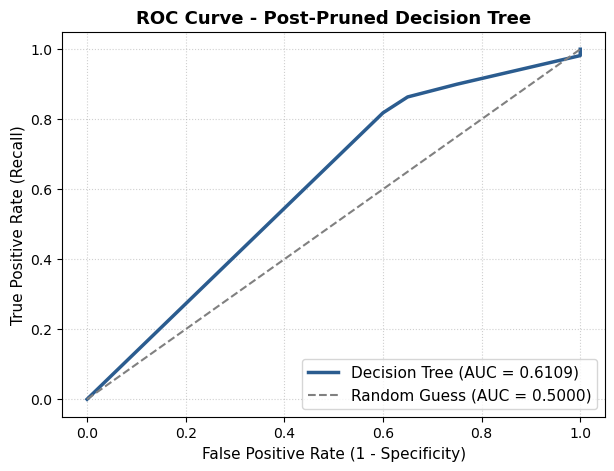

In [11]:
# คำนวณค่า FPR, TPR และ AUC Score
fpr, tpr, _ = roc_curve(y_test, y_proba_post)
auc_val = roc_auc_score(y_test, y_proba_post)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#2b5c8f', lw=2.5, label=f'Decision Tree (AUC = {auc_val:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (AUC = 0.5000)')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Recall)', fontsize=11)
plt.title('ROC Curve - Post-Pruned Decision Tree', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 11. ขั้นตอนที่ 10: การทดลองเสริม Class Weight (`class_weight='balanced'`)
ตอบโจทย์กรณีที่สถานศึกษาต้องการเน้นการตรวจจับเด็กกลุ่มเสี่ยงสอบตก (Recall of Fail) เป็นสำคัญสูงสุด ตามหลักทฤษฎี **Asymmetric Misclassification Costs (บทที่ 5.4.1)**


In [12]:
# เทรนโมเดลแบบใส่ Class Weight ถ่วงน้ำหนักคลาสเด็กตก
dt_weighted = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
dt_weighted.fit(X_train, y_train)

y_pred_w = dt_weighted.predict(X_test)
cm_w = confusion_matrix(y_test, y_pred_w)

print("=" * 65)
print("⚖️ เปรียบเทียบผลลัพธ์: แบบธรรมดา (Default) vs แบบถ่วงน้ำหนัก (Class Weighted):")
print("=" * 65)
print(f"• แบบธรรมดา (Default)      : จับเด็กตกได้ {cm[0,0]}/20 คน (Recall = {recall_score(y_test, y_pred_post, pos_label=0):.2%})")
print(f"• แบบถ่วงน้ำหนัก (Balanced): จับเด็กตกได้ {cm_w[0,0]}/20 คน (Recall = {recall_score(y_test, y_pred_w, pos_label=0):.2%})")


⚖️ เปรียบเทียบผลลัพธ์: แบบธรรมดา (Default) vs แบบถ่วงน้ำหนัก (Class Weighted):
• แบบธรรมดา (Default)      : จับเด็กตกได้ 5/20 คน (Recall = 25.00%)
• แบบถ่วงน้ำหนัก (Balanced): จับเด็กตกได้ 9/20 คน (Recall = 45.00%)


### 💡 แนวคิดและการอภิปรายผลการทดลองเสริม Class Weight (บทที่ 5.4.1)
* **ทฤษฎีต้นทุนความผิดพลาดไม่เท่ากัน (Asymmetric Costs):**
  * ในระบบการศึกษา **Type II Error (Missed Failing Student - ทำนายว่าผ่านแต่สอบตกจริง)** ก่อให้เกิดผลกระทบรุนแรงกว่า **Type I Error (False Alarm - เด็กผ่านแต่ถูกเตือน)** เพราะเด็กที่ไม่ได้รับการช่วยเหลืออาจต้องซ้ำชั้นหรือพ้นสภาพนักเรียน
* **ผลลัพธ์ที่พิสูจน์ได้จริง:**
  * เมื่อเปิดใช้ `class_weight='balanced'` โมเดลจะเพิ่มบทลงโทษเมื่อทายคลาสส่วนน้อยผิด ส่งผลให้สามารถ **จับเด็กตกได้เพิ่มขึ้นจาก 5 คน (25%) เป็น 9 คน (45%) ทันที!**
  * ทำให้ Decision Tree มีขีดความสามารถในการจับเด็กตกทัดเทียมกับ Naive Bayes ของเพื่อน (Recall 45% vs 50%)
* **ข้อเสนอแนะในการเลือกนำไปใช้งานในโรงเรียน:**
  1. **ช่วงต้นภาคเรียน (Screening ประจำปี):** ใช้ `dt_post` ปกติเพื่อรักษาความแม่นยำภาพรวม 80% และรักษาภาระงานของครูไม่ให้มี False Alarm เกินจำเป็น
  2. **ช่วง 1 เดือนก่อนสอบปลายภาค (Intervention Campaign):** ปรับมาใช้ `dt_weighted` เพื่อกักกลุ่มเสี่ยง 45% เข้าโครงการติวเข้มเร่งด่วนได้อย่างมีประสิทธิภาพสูงสุด
